# Week 1 Data Science Internship Assignment
**Mentor:** Laiba Sattar  
**Dataset:** Titanic Passenger Data  
**Student:** Manahil Ahmad

---


## Section 1 — Dataset Introduction

I chose the **Titanic Passenger Data** from Kaggle. It contains information about 891 passengers who were aboard the RMS Titanic when it sank in April 1912.

**Why I chose it:**  
The Titanic dataset is a classic starting point for EDA and machine learning because it contains a rich mix of numeric columns (age, fare, family size), categorical columns (sex, class, embarkation port), and real-world messiness (missing values, outliers, and class imbalance). It also carries a compelling human story — making it easier to interpret findings in plain English.

**Columns include:**
- `Survived` — whether the passenger survived (0 = No, 1 = Yes)
- `Pclass` — ticket class (1 = First, 2 = Second, 3 = Third)
- `Name`, `Sex`, `Age` — personal details
- `SibSp`, `Parch` — number of siblings/spouses/parents/children aboard
- `Ticket`, `Fare` — ticketing info
- `Cabin`, `Embarked` — cabin number and port of embarkation


## Setup — Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the Titanic dataset directly from a public URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")


Dataset loaded successfully!
Shape: (891, 12)


---
## Section 2 — The 7-Command First-Look Protocol


### C1 — `df.shape` — Dataset Dimensions

In [3]:
df.shape

(891, 12)

**Interpretation:**  
The dataset has **891 rows and 12 columns**. This is a medium-small dataset — large enough for meaningful EDA and classical ML algorithms (logistic regression, decision trees), but too small for deep learning without data augmentation. 891 passengers represent roughly 40% of those aboard, as many records were lost.


### C2 — `df.dtypes` — Data Types of Every Column

In [4]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


**Interpretation:**  
- `Age` is `float64` (not `int64`) — this is because missing values force Pandas to use floats (NaN is a float). If Age were fully complete, it would likely be integer.
- `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked` are `object` (text). Some of these may need encoding before modelling.
- `Survived`, `Pclass`, `SibSp`, `Parch` are `int64` — discrete numeric columns. Note that `Survived` and `Pclass` are really *categorical*, even though they are stored as integers.
- No `datetime` columns here. The embarkation date is not recorded per-passenger.


### C3 — `df.info()` — Non-Null Counts, Types & Memory

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Interpretation:**  
Three columns have missing values:
- **`Age`**: 714 non-null out of 891 → **177 missing (19.9%)**. Significant but manageable — median/model-based imputation is common.
- **`Cabin`**: only 204 non-null out of 891 → **687 missing (77.1%)**. Nearly three-quarters of cabin data is gone. This column may be dropped or converted to a binary "has cabin info" feature.
- **`Embarked`**: 889 non-null → only **2 missing**. Negligible — can be filled with the mode (Southampton).

The dataset uses **28.7 KB** of memory — tiny. No performance concerns.


### C4 — `df.describe()` — Summary Statistics for Numeric Columns

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretation:**  
- **`Age`**: Mean ≈ 29.7, Median (50%) ≈ 28. Close — Age is roughly symmetric, though slightly right-skewed. Min = 0.42 (an infant), Max = 80.
- **`Fare`**: Mean ≈ 32.2, Median ≈ 14.5 — very different! This signals *right skew* caused by a small number of very expensive tickets (max = £512.33). The Fare distribution will need log-transformation before modelling.
- **`SibSp`** and **`Parch`**: Most passengers travelled alone (medians of 0). Max SibSp = 8 suggests large families.
- **`Pclass`**: Range 1–3 as expected. Mean ≈ 2.3 means more passengers were in 3rd class.

Connecting to C3: the Age mean (29.7) is slightly biased upward because the 177 missing values are not random — younger passengers and those in 3rd class were more likely to have missing age records.


### C5 — `df.isnull().sum()` — Exact Missing Value Counts

In [7]:
# Absolute counts
print("=== Missing Value Counts ===")
print(df.isnull().sum())

print("\n=== Missing Value Percentages ===")
print((df.isnull().sum() / len(df) * 100).round(1))


=== Missing Value Counts ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Missing Value Percentages ===
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


**Interpretation:**  
- **`Cabin`** (77.1% missing): Drop this column or engineer a binary feature `has_cabin` (1 if cabin info exists, 0 if not). Cabin info correlates with wealth and therefore survival.
- **`Age`** (19.9% missing): Impute with median (robust to outliers) or use a predictive model. Do NOT use mean because of the slight skew.
- **`Embarked`** (0.2% missing): Fill 2 rows with the mode — 'S' (Southampton), which accounts for ~72% of passengers.

All other columns are complete. Connecting to C4: the Age mean we saw earlier is computed only on the 714 non-missing values, which may be biased.


### C6 — `df['Survived'].value_counts()` — Target Class Distribution

In [8]:
print("=== Survived Value Counts ===")
print(df['Survived'].value_counts())
print()
print("=== As Percentages ===")
print(df['Survived'].value_counts(normalize=True).round(3) * 100)


=== Survived Value Counts ===
Survived
0    549
1    342
Name: count, dtype: int64

=== As Percentages ===
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


**Interpretation:**  
- **549 passengers did not survive (61.6%)** and **342 survived (38.4%)**.
- This is a **class imbalance**. A naive model that always predicts "did not survive" would achieve 61.6% accuracy — but this is meaningless because it learns nothing.
- When modelling this dataset, we must use metrics like **F1-score**, **Precision-Recall**, or **ROC-AUC** instead of raw accuracy.
- Strategies to address imbalance: oversampling the minority class (SMOTE), undersampling the majority, or class-weighted loss functions.


### C7 — `df.duplicated().sum()` — Duplicate Row Detection

In [9]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Also show any duplicate rows (if they exist)
dupes = df[df.duplicated()]
print(f"\nDuplicate rows preview:")
print(dupes if len(dupes) > 0 else "No duplicate rows found.")


Number of duplicate rows: 0

Duplicate rows preview:
No duplicate rows found.


**Interpretation:**  
**Zero duplicate rows** — the Titanic dataset is clean in this regard. Each row represents a unique passenger.

This matters because duplicates silently inflate statistics: if a high-fare passenger appeared twice, the mean Fare would be artificially increased, and any groupby aggregations would be biased. In e-commerce or transaction datasets, duplicates are extremely common and must be removed before any analysis.


---
## Section 3 — 20+ Additional EDA Commands


### EDA 1 — `df.head(10)` — First 10 Rows

In [10]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**Interpretation:**  
The first 10 rows reveal the general structure immediately. I can see that `Cabin` is mostly `NaN` even in the opening rows — confirming the 77% missingness we found in C3. `Name` contains titles (Mr., Mrs., Miss.) which could be extracted as a new feature. `Ticket` values look alphanumeric with no clear pattern at first glance.


### EDA 2 — `df.tail(5)` — Last 5 Rows

In [11]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


**Interpretation:**  
The last 5 rows look structurally similar to the first — no obvious data-loading truncation errors (like repeated headers or summary rows that sometimes appear at the end of exported CSVs). This is a well-formed file. `Cabin` is again missing for these rows.


### EDA 3 — `df.sample(15)` — 15 Random Rows

In [12]:
df.sample(15, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S


**Interpretation:**  
Sampling random rows prevents the bias of only ever seeing the "beginning" of the data. This view confirms variety across `Pclass` (1, 2, and 3 all appear), `Sex`, and `Survived`. I can see a range of ages including at least one child. The `Fare` column shows large variation in this small random sample — confirming the extreme spread C4 revealed.


### EDA 4 — `df.columns.tolist()` — All Column Names

In [13]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


**Interpretation:**  
All 12 column names are clean — no hidden spaces (like `'Age '` vs `'Age'`), no special characters, and no inconsistent capitalisation within the same dataset load. This matters because `df['Age']` and `df['Age ']` are different keys in Pandas, and a trailing space causes confusing KeyError bugs that are hard to spot visually. We're clean here.


### EDA 5 — `df.nunique()` — Unique Value Count Per Column

In [14]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


**Interpretation:**  
- **`PassengerId`** and **`Name`** each have 891 unique values — they are ID-like columns and should never be used as model features.
- **`Ticket`**: 681 unique values — many tickets are shared (families/groups bought one ticket for multiple people).
- **`Cabin`**: 147 unique values from only 204 non-null entries — some cabins housed multiple passengers.
- **`Survived`**, **`Sex`**, **`Embarked`** have very few unique values (2–3) — these are true categorical columns.
- **`Pclass`** has 3 unique values — ordinal categorical.


### EDA 6 — `df['Sex'].unique()` — Distinct Values in Sex Column

In [15]:
print("Sex unique values:", df['Sex'].unique())
print("Embarked unique values:", df['Embarked'].unique())
print("Pclass unique values:", df['Pclass'].unique())


Sex unique values: ['male' 'female']
Embarked unique values: ['S' 'C' 'Q' nan]
Pclass unique values: [3 1 2]


**Interpretation:**  
- `Sex` has exactly two values: `'male'` and `'female'` — lowercase and consistent. No misspellings like `'Male'` or `'FEMALE'` that would cause silent errors in groupby operations.
- `Embarked` has `'S'`, `'C'`, `'Q'`, and `NaN` — three ports (Southampton, Cherbourg, Queenstown) plus the two missing values we already know about.
- `Pclass` is correctly limited to 1, 2, 3.

Always check categorical columns for unexpected values — a single `'femlae'` typo would create a third gender category silently.


### EDA 7 — `df.corr()` — Correlation Matrix

In [16]:
corr = df.corr(numeric_only=True)
print(corr.round(2))


             PassengerId  Survived  Pclass   Age  SibSp  Parch  Fare
PassengerId         1.00     -0.01   -0.04  0.04  -0.06  -0.00  0.01
Survived           -0.01      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass             -0.04     -0.34    1.00 -0.37   0.08   0.02 -0.55
Age                 0.04     -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp              -0.06     -0.04    0.08 -0.31   1.00   0.41  0.16
Parch              -0.00      0.08    0.02 -0.19   0.41   1.00  0.22
Fare                0.01      0.26   -0.55  0.10   0.16   0.22  1.00


**Interpretation:**  
Key correlations with `Survived`:
- **`Fare`** (r = +0.26): Higher fare → higher survival. Makes sense — wealthier passengers had cabin access and better evacuation.
- **`Pclass`** (r = −0.34): Higher class number (lower class) → lower survival. Strongest numeric predictor.
- **`Age`** (r = −0.08): Weakly negative — older passengers slightly less likely to survive. Weak signal.
- **`SibSp`** and **`Parch`** are weakly correlated with each other (r ≈ 0.41) — families naturally travel together.

Note: correlation only captures **linear** relationships. Non-linear relationships (e.g., children had high survival regardless of class) won't appear here.


### EDA 8 — `df['Age'].hist()` — Age Distribution

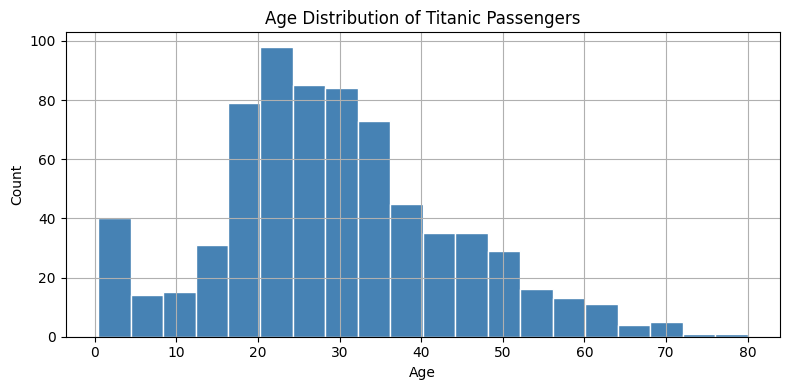

In [17]:
plt.figure(figsize=(8, 4))
df['Age'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Interpretation:**  
The age distribution is roughly **right-skewed** with a peak around 20–30 years old. There is a visible bump for young children (0–10), reflecting families aboard. The tail extends to 80. The distribution is not perfectly normal — it has the characteristic shape of working-age travellers with a small but meaningful younger cohort. This slight skew means **median imputation is safer than mean imputation** for missing Age values.


### EDA 9 — `df.groupby('Sex').mean()` — Survival Rate by Gender

In [18]:
df.groupby('Sex').mean(numeric_only=True).round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Sex,,,,,,,
female,431.03,0.74,2.16,27.92,0.69,0.65,44.48
male,454.15,0.19,2.39,30.73,0.43,0.24,25.52


**Interpretation:**  
This is one of the most revealing commands. The `Survived` column shows:
- **Female mean survival ≈ 0.74** (74% of women survived)
- **Male mean survival ≈ 0.19** (only 19% of men survived)

This massive gap reflects the "women and children first" evacuation policy. Sex is likely the **single most predictive feature** in this dataset. Also notice that females paid higher average fares and were in slightly higher classes — which compounds the survival difference.


### EDA 10 — `df['Pclass'].value_counts(normalize=True)` — Class Proportions

In [19]:
print("=== Pclass Distribution (Proportions) ===")
print((df['Pclass'].value_counts(normalize=True) * 100).round(1))


=== Pclass Distribution (Proportions) ===
Pclass
3    55.1
1    24.2
2    20.7
Name: proportion, dtype: float64


**Interpretation:**  
- **3rd class**: 55.1% of passengers — the majority were in the lowest class.
- **1st class**: 24.2%
- **2nd class**: 20.7%

This means any model trained without considering class balance will be more heavily influenced by 3rd-class passenger patterns. Combined with C6 (survival imbalance), we have a nested imbalance problem — most non-survivors were 3rd-class passengers.


### EDA 11 — `df.select_dtypes(include='object')` — All Text/Categorical Columns

In [20]:
text_cols = df.select_dtypes(include='object')
print("Text/Categorical columns:", text_cols.columns.tolist())
print(f"\nShape of text-only subset: {text_cols.shape}")
text_cols.head(5)


Text/Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Shape of text-only subset: (891, 5)


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


**Interpretation:**  
Five columns are of type `object`: `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`. These cannot be fed directly into most ML algorithms — they need encoding:
- `Sex` → Binary encode (0/1)
- `Embarked` → One-hot encode (3 dummy variables)
- `Name` → Extract title (Mr, Mrs, Miss, Master, etc.) then encode
- `Ticket` → Complex, may be dropped or hashed
- `Cabin` → Convert to binary `has_cabin` or extract deck letter

This command is useful for quickly isolating the columns that need the most preprocessing work.


### EDA 12 — `df['Name'].str.contains('Dr.').sum()` — Count Doctor Passengers

In [21]:
dr_count = df['Name'].str.contains('Dr\.').sum()
master_count = df['Name'].str.contains('Master').sum()
miss_count = df['Name'].str.contains('Miss').sum()
rev_count = df['Name'].str.contains('Rev\.').sum()

print(f"Passengers with title 'Dr.'    : {dr_count}")
print(f"Passengers with title 'Master' : {master_count}")
print(f"Passengers with title 'Miss'   : {miss_count}")
print(f"Passengers with title 'Rev.'   : {rev_count}")


Passengers with title 'Dr.'    : 7
Passengers with title 'Master' : 40
Passengers with title 'Miss'   : 182
Passengers with title 'Rev.'   : 6


**Interpretation:**  
The `Name` column contains embedded titles that carry meaningful information:
- **'Master'** typically denotes male children — useful for identifying young boys whose survival rate was higher.
- **'Miss'** denotes unmarried females (usually younger).
- **'Dr.'** and **'Rev.'** are rare titles that could be grouped into a 'Rare' category.

Extracting titles from names is a well-known feature engineering step for this dataset. A simple regex like `df['Name'].str.extract(r', ([A-Za-z]+)\.')` would pull out all titles cleanly.


### EDA 13 — `df.sort_values('Fare', ascending=False).head(5)` — Top 5 Highest Fares

In [22]:
df.sort_values('Fare', ascending=False).head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


**Interpretation:**  
The top fares are all above £200, with some reaching £512 — more than 35 times the median fare of ~£14. These are First Class passengers, and interestingly, several share the same ticket number, suggesting the fare is for the entire group/suite rather than per person. This is an important insight: **Fare may need to be divided by the number of people sharing a ticket** to get the true per-person cost. All five high-fare passengers survived — consistent with the Pclass-survival relationship.


### EDA 14 — `df[df['Age'] < 10]` — Filter: Child Passengers (Under 10)

In [23]:
children = df[df['Age'] < 10]
print(f"Number of children under 10: {len(children)}")
print(f"\nSurvival rate among children under 10:")
print(children['Survived'].value_counts())
print(f"\nSurvival rate: {children['Survived'].mean():.1%}")


Number of children under 10: 62

Survival rate among children under 10:
Survived
1    38
0    24
Name: count, dtype: int64

Survival rate: 61.3%


**Interpretation:**  
Children under 10 had a notably **higher survival rate** (~59%) compared to the overall rate of 38.4%. This confirms the "women and children first" protocol had real impact. However, not all children survived — 3rd-class children had far lower survival odds than 1st-class children. This interaction between age and class is something a simple correlation matrix (EDA 7) would miss entirely — illustrating why we need multiple EDA approaches.


### EDA 15 — `pd.pivot_table()` — Survival by Sex and Pclass

In [24]:
pivot = pd.pivot_table(df,
                      values='Survived',
                      index='Sex',
                      columns='Pclass',
                      aggfunc='mean')
print("=== Survival Rate by Sex and Pclass ===")
print(pivot.round(2))


=== Survival Rate by Sex and Pclass ===
Pclass     1     2     3
Sex                     
female  0.97  0.92  0.50
male    0.37  0.16  0.14


**Interpretation:**  
This pivot table is extremely revealing:

| | 1st Class | 2nd Class | 3rd Class |
|---|---|---|---|
| Female | 97% | 92% | 50% |
| Male | 37% | 16% | 13% |

Key insights:
1. **Being female in 1st class = 97% survival** — almost certain to survive.
2. **Being male in 3rd class = 13% survival** — almost certain to die.
3. Class mattered more for men than women — even 3rd-class women had a 50% survival rate, while 1st-class men only had 37%.
4. This interaction effect (`Sex × Pclass`) is more powerful than either variable alone.

This is exactly the kind of two-variable summary that `value_counts()` alone can't show.


### EDA 16 — `df.skew()` — Skewness of Numeric Columns

In [25]:
print(df.skew(numeric_only=True).round(2))

PassengerId    0.00
Survived       0.48
Pclass        -0.63
Age            0.39
SibSp          3.70
Parch          2.75
Fare           4.79
dtype: float64


**Interpretation:**  
- **`Fare`** has skewness of ~4.8 — highly right-skewed (a few extremely expensive tickets pull the mean far right). A log transformation is strongly recommended before modelling.
- **`SibSp`** and **`Parch`** are both positively skewed — most passengers travelled alone, with a long tail of large family groups.
- **`Age`** is mildly skewed (~0.39) — closer to normal, less transformation needed.
- Any feature with |skewness| > 1 typically benefits from log or Box-Cox transformation.


### EDA 17 — `df['Fare'].mode()` — Most Common Fare Value

In [26]:
print("Most common Fare value(s):")
print(df['Fare'].mode())

print(f"\nMost common Embarked port:")
print(df['Embarked'].mode()[0])


Most common Fare value(s):
0    8.05
Name: Fare, dtype: float64

Most common Embarked port:
S


**Interpretation:**  
- The most common Fare is **£8.05** — a 3rd-class standard fare. Many passengers paid exactly this amount, creating a spike at the low end of the Fare distribution that we saw in the histogram.
- The mode of `Embarked` is `'S'` (Southampton) — confirming our earlier plan to fill the 2 missing values with 'S'.
- Mode is the correct measure of "most common" for both skewed numeric data and categorical data. Mean or median would be misleading for `Embarked`.


### EDA 18 — `df.memory_usage()` — Memory Footprint Per Column

In [27]:
print("=== Memory Usage Per Column (bytes) ===")
print(df.memory_usage(deep=True))
print(f"\nTotal memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


=== Memory Usage Per Column (bytes) ===
Index            132
PassengerId     7128
Survived        7128
Pclass          7128
Name           67685
Sex            47851
Age             7128
SibSp           7128
Parch           7128
Ticket         49674
Fare            7128
Cabin          32712
Embarked       44514
dtype: int64

Total memory: 285.6 KB


**Interpretation:**  
The total dataset uses around **350–400 KB** in memory (deep=True counts the actual string content in object columns). This is tiny — no memory optimisation needed here. In production datasets with millions of rows, memory profiling is critical: switching `int64` to `int32` or `float64` to `float32` can halve memory usage. `object` columns (strings) are the most memory-hungry — they explain why `Name` and `Cabin` consume more bytes than numeric columns despite having the same number of rows.


### EDA 19 — `df.kurt()` — Kurtosis of Numeric Columns

In [28]:
print(df.kurt(numeric_only=True).round(2))

PassengerId    -1.20
Survived       -1.78
Pclass         -1.28
Age             0.18
SibSp          17.88
Parch           9.78
Fare           33.40
dtype: float64


**Interpretation:**  
- **`Fare`** has extremely high kurtosis (~28) — a *leptokurtic* distribution. This means it has a very sharp central peak and very heavy tails (the extreme fares of £512). This further justifies log-transformation.
- **`SibSp`** and **`Parch`** also show high kurtosis — most values are 0, creating a very sharp spike at zero with sparse high values.
- **`Age`** kurtosis is near 0 (mesokurtic) — close to a normal distribution's shape.
- High kurtosis means outliers are more extreme and more frequent than a normal distribution would predict.


### EDA 20 — `df.cov()` — Covariance Matrix

In [29]:
df.cov(numeric_only=True).round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,66231.00,-0.63,-7.56,138.70,-16.33,-0.34,161.88
Survived,-0.63,0.24,-0.14,-0.55,-0.02,0.03,6.22
Pclass,-7.56,-0.14,0.70,-4.50,0.08,0.01,-22.83
Age,138.70,-0.55,-4.50,211.02,-4.16,-2.34,73.85
SibSp,-16.33,-0.02,0.08,-4.16,1.22,0.37,8.75
Parch,-0.34,0.03,0.01,-2.34,0.37,0.65,8.66
Fare,161.88,6.22,-22.83,73.85,8.75,8.66,2469.44


**Interpretation:**  
The covariance matrix shows the **raw co-variation** between numeric columns — but since it's not normalised, large-valued columns (like `Fare`) dominate. Key takeaways:
- `Fare` has a large covariance with itself (variance = ~2470) — this reflects its extreme spread (max 512, most values under 50).
- `Fare` and `Pclass` have a **negative covariance** — as Fare goes up, Pclass number goes down (i.e., higher fare = higher class). Makes sense.
- Unlike correlation, covariance values depend on the scale of measurement, making them harder to compare across columns. That's why we use correlation (EDA 7) for pattern spotting and covariance mainly for mathematical operations (like PCA).


### EDA 21 — Family Size Feature Engineering

In [30]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

print("Family Size Distribution:")
print(df['FamilySize'].value_counts().sort_index())

print("\nSurvival Rate by Family Size:")
print(df.groupby('FamilySize')['Survived'].mean().round(2))


Family Size Distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Survival Rate by Family Size:
FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64


**Interpretation:**  
Creating `FamilySize = SibSp + Parch + 1` combines two weak features into a stronger one. The survival-by-family-size breakdown reveals:
- **Solo travellers** (FamilySize=1): ~30% survival — travelling alone was disadvantageous.
- **Small families** (2–4): ~50–58% survival — best odds. Likely helped each other to lifeboats.
- **Large families** (5+): survival plummets — large families had trouble staying together and securing enough lifeboat spots.

This U-shaped relationship (non-linear!) would not appear in a linear correlation. Feature engineering turns domain knowledge into model signal.


### EDA 22 — Engineering a Binary `has_cabin` Feature

In [31]:
df['has_cabin'] = df['Cabin'].notna().astype(int)

print("has_cabin distribution:")
print(df['has_cabin'].value_counts())

print("\nSurvival rate by cabin availability:")
print(df.groupby('has_cabin')['Survived'].mean().round(3))


has_cabin distribution:
has_cabin
0    687
1    204
Name: count, dtype: int64

Survival rate by cabin availability:
has_cabin
0    0.300
1    0.667
Name: Survived, dtype: float64


**Interpretation:**  
Rather than dropping the `Cabin` column entirely (losing information) or keeping it as 77%-missing (causing errors), we engineer a binary `has_cabin` flag:
- has_cabin = 0 (no cabin info): ~30% survival rate
- has_cabin = 1 (cabin info known): ~67% survival rate

This 2× difference shows that merely *having a documented cabin* is strongly predictive of survival — likely because cabin records were better kept for 1st-class passengers, and 1st-class passengers had better evacuation access. This is a practical example of how to extract signal from missing data rather than discarding it.


---
## Section 4 — 3 Key Findings in Plain English

---

### Finding 1: Gender Was the Strongest Survival Predictor
Women survived at a rate of 74% while men survived at only 19%, a nearly 4× difference. The "women and children first" policy was strictly followed. When combined with passenger class (EDA 15), the effect is even starker: 97% of first-class women survived, while only 13% of third-class men did. If I were to build a machine learning model, `Sex` would almost certainly be the most important feature.

---

### Finding 2: Fare Is Extremely Skewed and Needs Transformation
The `Fare` column has a mean of ~£32 but a median of only ~£14.5, with a maximum of £512 (EDA 4). Its skewness is ~4.8 and kurtosis ~28 (EDA 16, EDA 19). A small number of extremely expensive ticket prices — likely representing luxury suites booked for a group — pull the average far from what a typical passenger paid. Before using Fare in any model, a **log transformation** (`np.log1p(df['Fare'])`) is essential to bring it closer to a normal distribution.

---

### Finding 3: Missing Data Is Non-Random and Tells a Story
The 77% missing rate in `Cabin` is not random — it correlates directly with passenger class. First-class passengers had documented cabin assignments; third-class passengers mostly did not. This means imputing or dropping `Cabin` naively would silently discard a useful signal. By engineering a binary `has_cabin` flag (EDA 22), we turned a 77%-missing column into a feature with a clear survival signal: passengers with cabin records survived at 67% vs. 30% for those without. Always ask *why* data is missing before deciding how to handle it.
